##  Project Title:
 Bank Marketing Subscription Prediction using PCA and SVM

 Objective:
 Predict whether a client will subscribe to a term deposit.

 Dataset:
 Bank Marketing Dataset (bank-additional-full.csv)
 Records: 41,188
 Features: 20+

 Complete Workflow:
 1. Dataset Verification
 2. Exploratory Data Analysis (EDA)
 3. Train-Test Split (Before preprocessing to avoid leakage)
 4. Data Cleaning
 5. Data Preprocessing
 6. Dimensionality Reduction using PCA
 7. SVM Model Development
 8. Hyperparameter Tuning
 9. Model Evaluation
 10. Final Summary

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load dataset
df = pd.read_csv(r"D:\University\Semester 6\Data Computation\Assignments\Final Project\bank-additional-full.csv", sep=';')
print("\nDataset Loaded Successfully")
print(f"\nDataset Shape: {df.shape}")


Dataset Loaded Successfully

Dataset Shape: (41188, 21)


In [4]:
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   4118

In [7]:
print("\nDataset Summary Statistics:")
df.describe()



Dataset Summary Statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## # Requirement:
 Dataset must contain:
 - More than 10,000 records
 - At least 20 features

In [8]:
rows = df.shape[0]
columns = df.shape[1]
print(f"\nTotal Rows: {rows}")
print(f"Total Columns: {columns}")
if rows > 10000:
    print("PASS — Dataset contains more than 10,000 rows")
else:
    print("FAIL — Dataset does not satisfy row requirement")

if columns >= 20:
    print("PASS — Dataset contains at least 20 features")
else:
    print("FAIL — Dataset does not satisfy feature requirement")


Total Rows: 41188
Total Columns: 21
PASS — Dataset contains more than 10,000 rows
PASS — Dataset contains at least 20 features


##  DATA UNDERSTANDING...

In [9]:
print("\nColumn Names:")
df.columns.tolist()


Column Names:


['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [10]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [12]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())

duplicate_rows_before = df.duplicated().sum()
df = df.drop_duplicates()
duplicate_rows_after = df.duplicated().sum()

print(f"\n Duplicate rows removed: {duplicate_rows_before} → {duplicate_rows_after}")


Duplicate Rows:
12

 Duplicate rows removed: 12 → 0


In [13]:
print("\nTarget Variable Distribution:")
df['y'].value_counts()


Target Variable Distribution:


y
no     36537
yes     4639
Name: count, dtype: int64

## FEATURE GROUPING..
 We divide features into:
   1. Numerical Features
   2. Categorical Features

In [14]:
numerical_features = [
    'age',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

categorical_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'day_of_week',
    'poutcome'
]

## TARGET ENCODING
 Convert target variable:
   yes -> 1
   no  -> 0

In [15]:
df['target'] = df['y'].map({'yes': 1, 'no': 0})

##  REQUIREMENT 2: EXPLORATORY DATA ANALYSIS (EDA)
EDA 1 — TARGET VARIABLE DISTRIBUTION
 The dataset is imbalanced.
 
 Most clients did NOT subscribe.

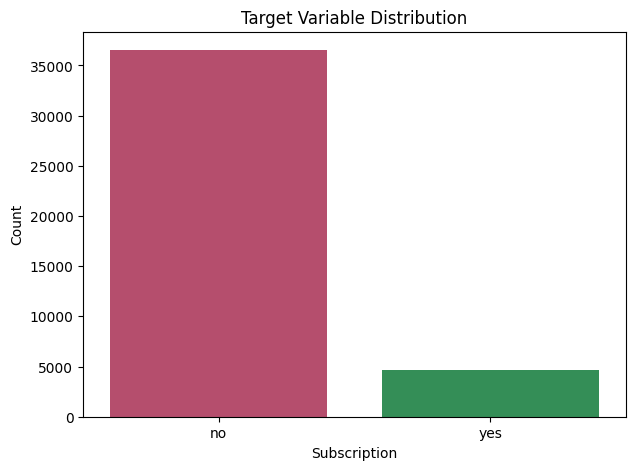

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='y',
    palette=["#C63D66", "#259D53"]
)
plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

## EDA 2 — DURATION VS TARGET
Clients with longer call duration are more likely to subscribe.

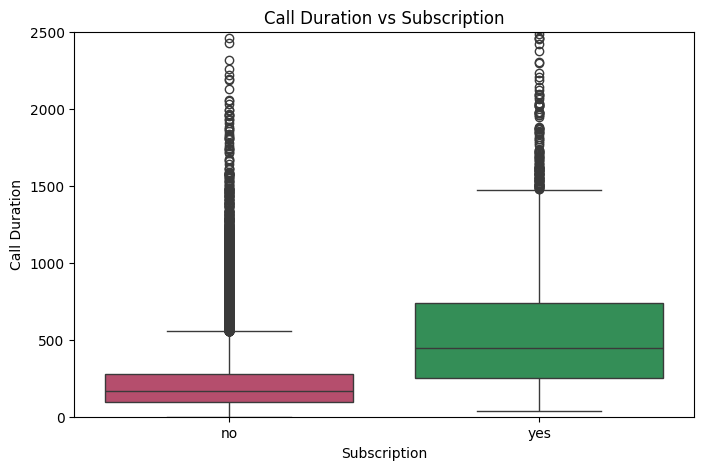

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='y',
    y='duration',
    palette=['#C63D66', '#259D53']
)
plt.title("Call Duration vs Subscription")
plt.xlabel("Subscription")
plt.ylabel("Call Duration")
plt.ylim(0, 2500)
plt.show()

## EDA 3 — PREVIOUS CAMPAIGN OUTCOME
Clients with previous successful outcomes

 have much higher probability of subscribing.

<Figure size 800x500 with 0 Axes>

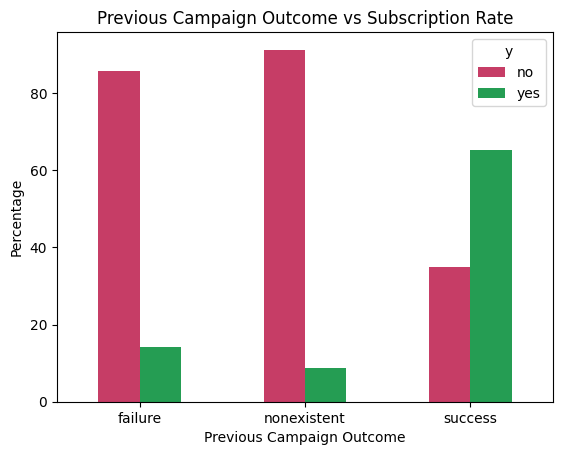

In [18]:
plt.figure(figsize=(8,5))
poutcome_rate = pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize='index'
) * 100
poutcome_rate.plot(
    kind='bar',
    color=['#C63D66', '#259D53']
)
plt.title("Previous Campaign Outcome vs Subscription Rate")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

## EDA 4 — MONTHLY SUBSCRIPTION RATE
 Some months achieve better marketing performance than others.

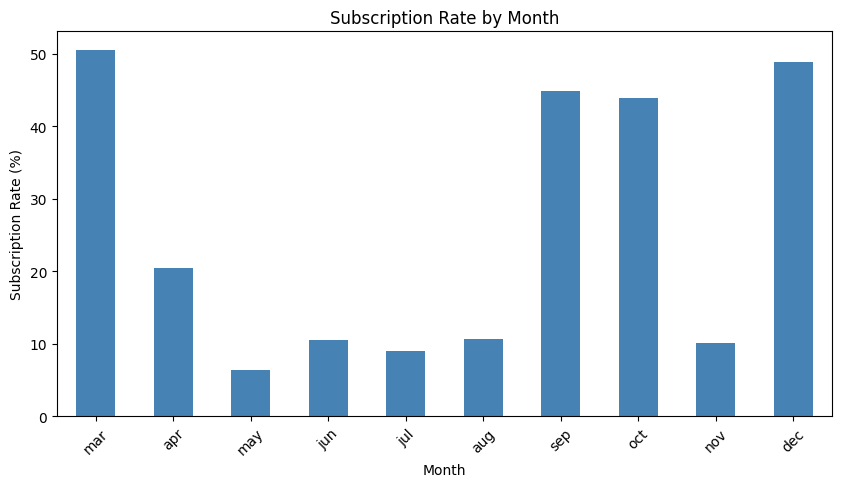

In [19]:
plt.figure(figsize=(10,5))
month_rate = df.groupby('month')['target'].mean() * 100
month_order = [
    'mar','apr','may','jun',
    'jul','aug','sep','oct',
    'nov','dec'
]
month_rate = month_rate.reindex(month_order)
month_rate.plot(
    kind='bar',
    color='steelblue'
)
plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.show()

## EDA 5 — JOB CATEGORY ANALYSIS
Students and retired clients usually show

 higher subscription rates.

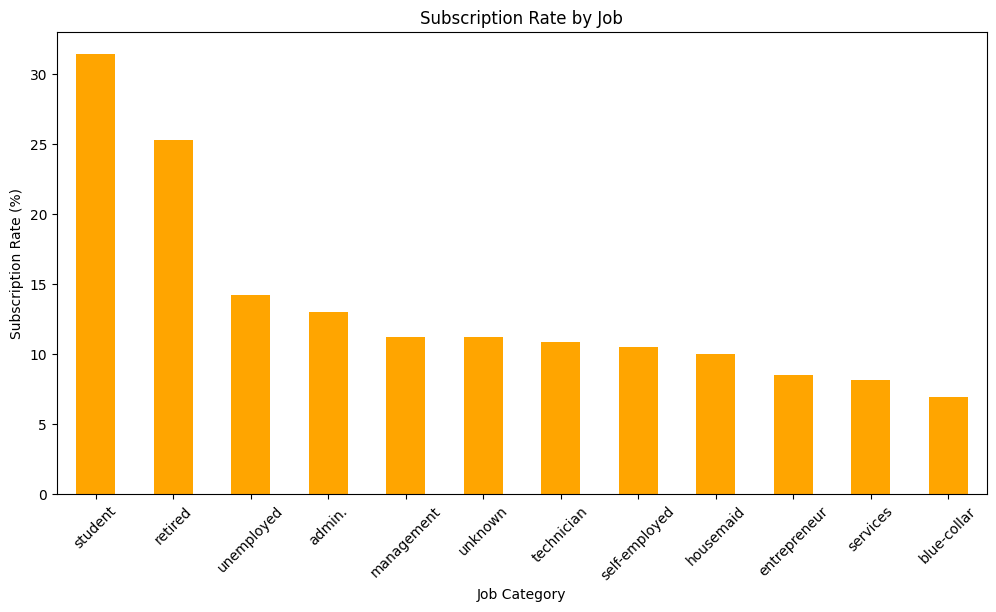

In [20]:
plt.figure(figsize=(12,6))
job_rate = df.groupby('job')['target'].mean() * 100
job_rate = job_rate.sort_values(ascending=False)
job_rate.plot(
    kind='bar',
    color='orange'
)
plt.title("Subscription Rate by Job")
plt.xlabel("Job Category")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.show()

## EDA 6 — CORRELATION HEATMAP
Some economic indicators are highly correlated

especially euribor3m and emp.var.rate.

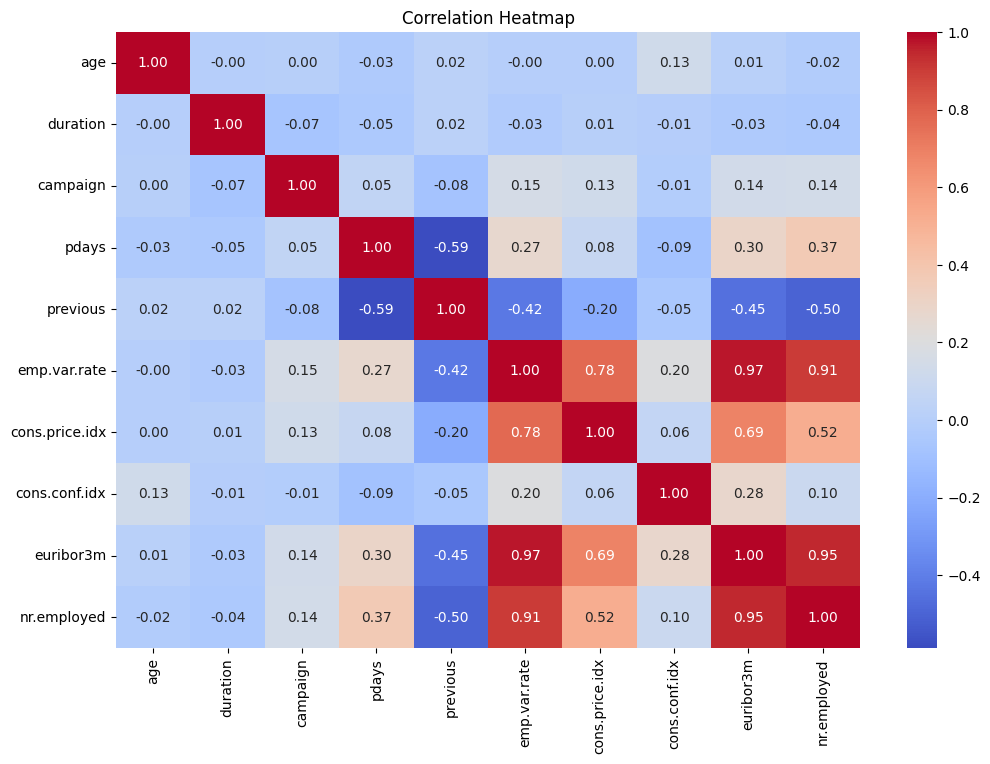

In [21]:
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

## TRAIN TEST SPLIT
We split BEFORE preprocessing to avoid DATA LEAKAGE.

In [22]:
X = df.drop(['y', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nTraining Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")


Training Shape: (32940, 20)
Testing Shape: (8236, 20)


## REQUIREMENT 3: DATA CLEANING
  HANDLE UNKNOWN VALUES

In this dataset, "unknown" acts like missing values.

 We replace them using mode from TRAINING data only.

In [23]:
for col in categorical_features:
    if 'unknown' in X_train[col].values:
        mode_value = X_train.loc[
            X_train[col] != 'unknown',
            col
        ].mode()[0]
        X_train[col] = X_train[col].replace(
            'unknown',
            mode_value
        )
        X_test[col] = X_test[col].replace(
            'unknown',
            mode_value
        )
print("\nUnknown values handled successfully")


Unknown values handled successfully


## HANDLE OUTLIERS USING IQR CAPPING..

 We CAP outliers instead of removing them.
 
 This preserves dataset size.

In [24]:
for col in numerical_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train[col] = X_train[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )
    X_test[col] = X_test[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )
print("Outliers capped successfully")

Outliers capped successfully


## DATA PREPROCESSING PIPELINE
 Numerical Data:
 - Median Imputation
 - Standard Scaling
 
 Categorical Data:
 - Most Frequent Imputation
 - One Hot Encoding

In [25]:
# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        handle_unknown='ignore'
    ))
])
# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])
# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)
# Transform testing data
X_test_processed = preprocessor.transform(X_test)
print("\nPreprocessing completed successfully")
print(f"\nProcessed Training Shape: {X_train_processed.shape}")
print(f"Processed Testing Shape: {X_test_processed.shape}")


Preprocessing completed successfully

Processed Training Shape: (32940, 47)
Processed Testing Shape: (8236, 47)


## REQUIREMENT 4: PCA
 PCA reduces dimensionality while preserving information.


Original Features: 47
Optimal PCA Components: 22
Variance Preserved: 95.32%


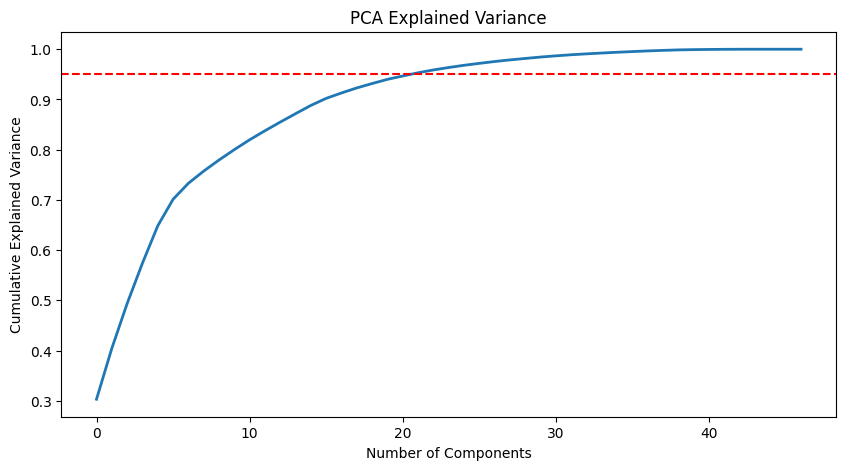


PCA Applied Successfully

Reduced Dimensions: 22


In [26]:
# Initialize PCA
pca = PCA()
# Fit PCA
pca.fit(X_train_processed)
# Calculate cumulative variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)
# Find components for 95% variance
n_components = np.argmax(
    cumulative_variance >= 0.95
) + 1
print(f"\nOriginal Features: {X_train_processed.shape[1]}")
print(f"Optimal PCA Components: {n_components}")
print(f"Variance Preserved: {cumulative_variance[n_components-1]*100:.2f}%")
# PCA variance plot
plt.figure(figsize=(10,5))
plt.plot(
    cumulative_variance,
    linewidth=2
)
plt.axhline(
    y=0.95,
    color='red',
    linestyle='--'
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()
# Final PCA
pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(
    X_train_processed
)
X_test_pca = pca_final.transform(
    X_test_processed
)
print("\nPCA Applied Successfully")
print(f"\nReduced Dimensions: {X_train_pca.shape[1]}")

##  REQUIREMENT 5: Support Vector Machine (SVM) MODEL DEVELOPMENT
 BASE SVM MODEL

In [27]:
base_svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)
# Train model
base_svm.fit(
    X_train_pca,
    y_train
)
# Predictions
y_pred_base = base_svm.predict(
    X_test_pca
)
# Base metrics
base_accuracy = accuracy_score(
    y_test,
    y_pred_base
)
base_f1 = f1_score(
    y_test,
    y_pred_base
)
print("\nBase SVM Performance")
print(f"Accuracy: {base_accuracy:.4f}")
print(f"F1 Score: {base_f1:.4f}")


Base SVM Performance
Accuracy: 0.8479
F1 Score: 0.5819


## HYPERPARAMETER TUNING
 We use GridSearchCV to find best parameters.

In [28]:
print("\nRunning GridSearchCV...")
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1],
    'kernel': ['rbf']
}
grid_search = GridSearchCV(
    estimator=SVC(
        class_weight='balanced',
        random_state=42
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_search.fit(
    X_train_pca,
    y_train
)
print("\nBest Parameters:")
print(grid_search.best_params_)
print(f"\nBest Cross Validation F1: {grid_search.best_score_:.4f}")


Running GridSearchCV...

Best Parameters:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Best Cross Validation F1: 0.5807


## BEST MODEL EVALUATION

In [29]:
best_model = grid_search.best_estimator_
# Predictions
y_pred = best_model.predict(X_test_pca)
# Decision scores
y_scores = best_model.decision_function(
    X_test_pca
)
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_scores)
print("\nFINAL MODEL PERFORMANCE")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")


FINAL MODEL PERFORMANCE
Accuracy  : 0.8703
Precision : 0.4588
Recall    : 0.8405
F1 Score  : 0.5936
ROC AUC   : 0.9272


## CROSS VALIDATION

In [30]:
cv_scores = cross_val_score(
    best_model,
    X_train_pca,
    y_train,
    cv=5,
    scoring='f1'
)
print("\nCross Validation Scores:")
print(cv_scores)
print(f"\nMean CV F1 Score: {cv_scores.mean():.4f}")


Cross Validation Scores:
[0.58745247 0.57902231 0.58597502 0.57939509 0.57171216]

Mean CV F1 Score: 0.5807


##  CONFUSION MATRIX
 Shows TP, TN, FP, FN.

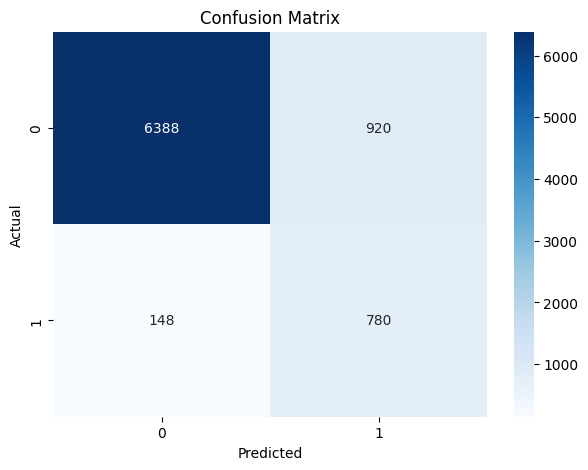

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ROC CURVE
 Higher AUC means better classification performance.

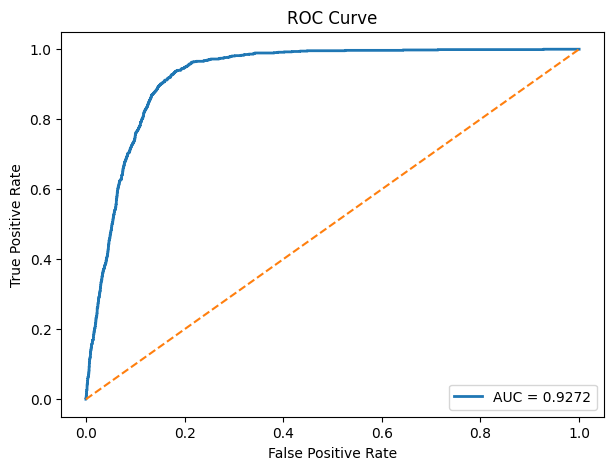

In [32]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_scores
)
plt.figure(figsize=(7,5))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## CLASSIFICATION REPORT

In [33]:
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report
              precision    recall  f1-score   support

           0       0.98      0.87      0.92      7308
           1       0.46      0.84      0.59       928

    accuracy                           0.87      8236
   macro avg       0.72      0.86      0.76      8236
weighted avg       0.92      0.87      0.89      8236



## FINAL PROJECT SUMMARY

In [34]:
print("FINAL PROJECT SUMMARY")
print(f"""
1. DATASET REQUIREMENT
----------------------------------------
 Rows: {df.shape[0]}
 Columns: {df.shape[1]}

2. EDA REQUIREMENT
----------------------------------------
 Target distribution analyzed
 Relationships analyzed
 No repeated visualizations

3. DATA CLEANING REQUIREMENT
----------------------------------------
 Unknown values handled
 Outliers capped
 No records dropped

4. PCA REQUIREMENT
----------------------------------------
 PCA applied successfully
 Components selected using 95% variance rule
 Reduced dimensions from {X_train_processed.shape[1]} to {n_components}

5. SVM REQUIREMENT
----------------------------------------
 SVM classification model built
 Hyperparameter tuning applied
 Cross validation applied
 Evaluation metrics calculated

FINAL MODEL RESULTS
----------------------------------------
Accuracy  : {accuracy:.4f}
Precision : {precision:.4f}
Recall    : {recall:.4f}
F1 Score  : {f1:.4f}
ROC AUC   : {roc_auc:.4f}
""")
print("PROJECT COMPLETED SUCCESSFULLY")

FINAL PROJECT SUMMARY

1. DATASET REQUIREMENT
----------------------------------------
 Rows: 41176
 Columns: 22

2. EDA REQUIREMENT
----------------------------------------
 Target distribution analyzed
 Relationships analyzed
 No repeated visualizations

3. DATA CLEANING REQUIREMENT
----------------------------------------
 Unknown values handled
 Outliers capped
 No records dropped

4. PCA REQUIREMENT
----------------------------------------
 PCA applied successfully
 Components selected using 95% variance rule
 Reduced dimensions from 47 to 22

5. SVM REQUIREMENT
----------------------------------------
 SVM classification model built
 Hyperparameter tuning applied
 Cross validation applied
 Evaluation metrics calculated

FINAL MODEL RESULTS
----------------------------------------
Accuracy  : 0.8703
Precision : 0.4588
Recall    : 0.8405
F1 Score  : 0.5936
ROC AUC   : 0.9272

PROJECT COMPLETED SUCCESSFULLY


In [35]:
import pickle
import joblib
with open('best_svm_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('pca_final.pkl', 'wb') as f:
    pickle.dump(pca_final, f)
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print(" Models saved!")

 Models saved!
